# HealthConnect Clinic - No-Show Prediction
## Data Science Track - Week 8: Final Model Selection, Documentation & Presentation

**Project:** AnalystLab Africa Experience Lab

**Author:** Ange Maxime

**Week:** 8 - Final Integration, Presentation & Project Showcase

**Builds on:** `HealthConnect_Week7_ModelTesting_Refinement.ipynb` 

(Week 7). This notebook does **not** repeat Week 7's stability, overfitting, or fairness *testing* procedures - it takes the Week 7 tested model as given, resolves the one item Week 7 left open (the `historical_no_show_rate` multicollinearity), finalises the candidate model, and packages it for presentation and hand-off.

---
### Contents
1. [Week 7 → Week 8 Transition](#1)
2. [Part - Final Integration Readiness](#2)
3. [Rebuilding the Week 7 Tested Model](#3)
4. [Resolving the Multicollinearity Finding - Before/After Test](#4)
5. [Final Candidate Model](#5)
6. [Baseline vs. Final Comparison (Week 5 → Week 8)](#6)
7. [Final Evaluation](#7)
8. [Error Analysis Summary](#8)
9. [Consolidated Feature & Model Decision Log (Weeks 4–8)](#9)
10. [Business Interpretation & Suitability](#10)
11. [What This Model Can and Cannot Be Used For](#11)
12. [Final Limitations & Risks](#12)
13. [Final Model Documentation & Hand-off Package](#13)
14. [Mandatory HC-POD Final Integration](#14)
15. [Final End-to-End Integration Walkthrough](#15)
16. [Non-Technical Model Summary](#16)
17. [Week 8 Project Summary](#17)


<a id="1"></a>
## 1. Week 7 → Week 8 Transition

*(Concise, per the assignment's Part 3 - full detail is in the Week 7 notebook, not repeated here.)*

1. **Main Week 7 output.** A refined, tested Logistic Regression model (`age` and `gender` excluded, Sunday-dated appointments excluded) with a serialised artefact (`healthconnect_noshow_model_v2.joblib`), validated by 10 independent patient-grouped splits (ROC-AUC 0.688 ± 0.012), an overfitting check (0.005 train-test gap), and a full-sample fairness audit.
2. **Most important testing result.** The model is stable and not overfitting.  The ~0.69 ROC-AUC ceiling is a genuine limit of the available signal, not a modelling defect and the age-fairness concern flagged in Week 6 was confirmed real (though smaller than first estimated) and substantially reduced by dropping `age`.
3. **Major issue discovered during testing.** `historical_no_show_rate`'s fitted coefficient had the *wrong sign* (negative, when its real-world relationship with no-shows is strongly positive), caused by multicollinearity with `previous_no_shows` (r = 0.79). This doesn't hurt prediction, but it undermines the model's usability as an *explainable* tool for clinic staff, which is part of its original justification.
4. **What was refined or improved.** `age` was removed as a model input (zero accuracy cost, nearly halved the age-related flagging-rate gap), and a tested, reloadable model artefact was produced for the first time.
5. **Which component is now considered ready.** The model's core stability, absence of overfitting, and pipeline reliability (serialisation, missing values, unseen categories, malformed input) are all directly tested and confirmed.
6. **What still needs to be integrated / resolved this week.** The multicollinearity finding (fixed below, §4), a final baseline-vs-final performance comparison, consolidated business interpretation and limitations documentation, and packaging everything for cross-track hand-off and presentation.
7. **Track(s) involved in final integration.** Data Science (owner, this notebook); Machine Learning Engineering (final artefact hand-off, §14); Data Analytics (validated attendance/no-show pattern findings informing business interpretation, §14, see the scope note there); Project Management (coordinates the final presentation, referenced but not owned by this notebook).
8. **What this notebook intends to demonstrate.** That the Week 4–7 modelling work resolves into one final, documented, business-interpretable model,  with a clean feature set, a clear statement of what it can and cannot be used for, and a tested hand-off artefact - ready for the Week 8 showcase.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                              RocCurveDisplay, classification_report)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

<a id="2"></a>
## 2. Part 1 - Final Integration Readiness

| Requirement | Response |
|---|---|
| **What is my final component?** | A Logistic Regression appointment no-show risk-scoring model (preprocessing + model, packaged as one `scikit-learn` pipeline), producing a probability that a given scheduled appointment will end in a no-show. |
| **What problem does it address?** | Identifies, before an appointment happens, which scheduled appointments are at elevated risk of an unannounced no-show, so clinic staff can prioritise limited outreach capacity (reminder calls, reschedule offers). |
| **What is its current status?** | Finalised and tested. Stability, overfitting, and fairness were directly tested in Week 7; the one open interpretability issue (multicollinearity) is resolved in this notebook (§4); a fresh, final serialised artefact is produced (§13). Not production-deployed. This remains a demonstrated, hand-off-ready prototype. |
| **What did I improve during Week 7 (carried into Week 8)?** | Removed `age` (fairness gap nearly halved at no accuracy cost); produced and tested the first serialised model artefact; confirmed stability and absence of overfitting with direct evidence rather than assumption. |
| **Which other track(s) does it depend on?** | Data Analytics validated attendance/no-show pattern findings that cross-check this model's feature choices and business interpretation (§14, with a scope note on how this was fulfilled). Project Management coordinates the final presentation sequence this notebook feeds into. |
| **Which track(s) depend on my output?** | Machine Learning Engineering consumes the final serialised artefact and its interface specification (§13, §14) for any future pipeline integration. Project Management uses this notebook's business interpretation (§10) and non-technical summary (§16) in the final HealthConnect presentation. |
| **What output will I provide?** | The final tested model artefact (`healthconnect_noshow_model_final.joblib`), its documented input/output interface (§13), evaluation results (§7), and a non-technical summary (§16). |
| **What output do I need from another track?** | Data Analytics' validated KPI/pattern findings, to confirm this model's feature importances are consistent with the clinic-wide analytical picture rather than an artefact of the modelling approach alone (addressed via the good-faith stand-in described in §14, given this internship's single-contributor scope). |
| **What evidence demonstrates readiness?** | Week 7's stability, overfitting, and pipeline-reliability tests; this notebook's multicollinearity resolution (§4), baseline-vs-final comparison (§6), full evaluation suite (§7), and error analysis (§8). |
| **What limitations remain?** | `waiting_time_minutes` timing still unresolved (needs a business-owner decision); the 0.44 operating threshold has been tested for statistical stability but not reviewed by a clinic stakeholder against real intervention costs; a residual (reduced but non-zero) age-related fairness gap warrants continued monitoring; the dataset is synthetic throughout. Full list in §12. |


<a id="3"></a>
## 3. Rebuilding the Week 7 Tested Model

Same cleaning and feature engineering as Weeks 6–7 (Sunday-dated appointments excluded after the Knowledge Base cross-check; `historical_no_show_rate` / `is_new_patient` / `is_weekend` / `lead_time_bucket` engineered; `gender` and `age` excluded per Week 6–7's fairness-driven refinements), reproduced here only so this notebook is self-contained. The original CSV is never modified.


In [2]:
raw = pd.read_csv(r'C:\Users\Ange\Downloads\Training Data S. africa Lab\week 8\Data\HealthConnect_Appointment_Data.csv')
df = raw.copy()
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')
df['reminder_channel'] = df['reminder_channel'].fillna('None')

binary_df = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
binary_df['target'] = (binary_df['appointment_outcome'] == 'No-Show').astype(int)
cleaned = binary_df[binary_df['appointment_day'] != 'Sunday'].copy()

cleaned['historical_no_show_rate'] = np.where(
    cleaned['previous_appointments'] > 0,
    cleaned['previous_no_shows'] / cleaned['previous_appointments'], 0.0)
cleaned['is_new_patient'] = (cleaned['previous_appointments'] == 0).astype(int)
cleaned['is_weekend'] = cleaned['appointment_day'].isin(['Saturday']).astype(int)
cleaned['lead_time_bucket'] = pd.cut(
    cleaned['booking_lead_days'], bins=[-1, 7, 14, 30, 45, 60],
    labels=['0-7', '8-14', '15-30', '31-45', '46-60']).astype(str)

num_w7 = ['booking_lead_days', 'previous_appointments', 'previous_no_shows',
          'distance_to_clinic_km', 'historical_no_show_rate', 'is_new_patient', 'is_weekend']
cat_cols = ['appointment_type', 'appointment_time', 'appointment_day', 'reminder_sent',
            'reminder_channel', 'lead_time_bucket']

X_w7 = cleaned[num_w7 + cat_cols]
y = cleaned['target']
groups = cleaned['patient_id']

pre_w7 = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_w7),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])
model_w7 = Pipeline([('preprocess', pre_w7), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])

gkf = GroupKFold(n_splits=5)
cv_w7 = cross_validate(model_w7, X_w7, y, groups=groups, cv=gkf,
                        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
print(f"Modelling dataset: {len(X_w7):,} rows, {X_w7.shape[1]} raw columns, {cleaned['patient_id'].nunique()} patients")
print("Reproduced Week 7 model, 5-fold CV: " +
      " ".join(f"{k.replace('test_','')}={np.mean(v):.3f}" for k, v in cv_w7.items() if k.startswith('test_')))
print("(Matches Week 7's reported 0.685 ROC-AUC.)")

Modelling dataset: 4,033 rows, 13 raw columns, 1605 patients
Reproduced Week 7 model, 5-fold CV: accuracy=0.631 precision=0.639 recall=0.636 f1=0.637 roc_auc=0.684
(Matches Week 7's reported 0.685 ROC-AUC.)


<a id="4"></a>
## 4. Resolving the Multicollinearity Finding Before/After Test

**The issue (from Week 7, §8 there).** `historical_no_show_rate` and `previous_no_shows` correlate at r = 0.79 (both are built from the same two underlying counts). This lets the linear model split credit between them arbitrarily. `historical_no_show_rate`'s fitted coefficient came out **negative**, contradicting its clearly positive real-world relationship with no-shows established back in Weeks 4–5. This doesn't hurt accuracy, but it does undermine the model's explainability, which matters because clinic staff are the intended audience for these coefficients.

**Test design.** Three candidate fixes are compared against the Week 7 model (both features retained) by 5-fold patient-grouped cross-validation, checking both predictive performance and whether `previous_no_shows`' coefficient sign becomes correct:

- **Option A** drop `historical_no_show_rate`, keep `previous_no_shows` and `previous_appointments`.
- **Option B** drop `previous_no_shows`, keep `historical_no_show_rate` and `previous_appointments`.
- **Option C** drop both `historical_no_show_rate` and `previous_appointments`, keep only `previous_no_shows`.


In [3]:
def evaluate_feature_set(num_cols, label):
    X = cleaned[num_cols + cat_cols]
    pre = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ])
    pipe = Pipeline([('preprocess', pre), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    cv = cross_validate(pipe, X, y, groups=groups, cv=gkf, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

    full = Pipeline([('preprocess', pre), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    full.fit(X, y)
    feat_names = full.named_steps['preprocess'].get_feature_names_out()
    coefs = full.named_steps['model'].coef_[0]
    coef_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs}).sort_values('coefficient', key=abs, ascending=False)

    row = {'Option': label, 'n_features': len(num_cols) + len(cat_cols)}
    row.update({k.replace('test_', ''): np.mean(v) for k, v in cv.items() if k.startswith('test_')})
    prev_ns_coef = coef_df.loc[coef_df.feature == 'num__previous_no_shows', 'coefficient']
    hist_coef = coef_df.loc[coef_df.feature == 'num__historical_no_show_rate', 'coefficient']
    row['previous_no_shows sign'] = ('+' if prev_ns_coef.iloc[0] > 0 else '-') if len(prev_ns_coef) else 'n/a (dropped)'
    row['historical_no_show_rate sign'] = ('+' if hist_coef.iloc[0] > 0 else '-') if len(hist_coef) else 'n/a (dropped)'
    return row, coef_df

results = []
row, _ = evaluate_feature_set(num_w7, 'Week 7 (both features)'); results.append(row)
optA_num = [c for c in num_w7 if c != 'historical_no_show_rate']
row, coef_A = evaluate_feature_set(optA_num, 'Option A: drop historical_no_show_rate'); results.append(row)
optB_num = [c for c in num_w7 if c != 'previous_no_shows']
row, coef_B = evaluate_feature_set(optB_num, 'Option B: drop previous_no_shows'); results.append(row)
optC_num = [c for c in num_w7 if c not in ('historical_no_show_rate', 'previous_appointments')]
row, coef_C = evaluate_feature_set(optC_num, 'Option C: drop both, keep previous_no_shows only'); results.append(row)

comparison = pd.DataFrame(results).set_index('Option').round(3)
comparison

,n_features,accuracy,precision,recall,f1,roc_auc,previous_no_shows sign,historical_no_show_rate sign
Option,,,,,,,,
Week 7 (both features),13,0.631,0.639,0.636,0.637,0.684,+,-
Option A: drop historical_no_show_rate,12,0.633,0.641,0.636,0.638,0.683,+,n/a (dropped)
Option B: drop previous_no_shows,12,0.632,0.640,0.637,0.638,0.678,n/a (dropped),+
"Option C: drop both, keep previous_no_shows only",11,0.631,0.639,0.636,0.637,0.684,+,n/a (dropped)


**Result.** All three fixes cost essentially nothing in ROC-AUC (0.684 vs. Week 7's 0.685 well inside the ±0.011–0.012 split-to-split noise Week 7's stability test established), and both Option A and Option C flip `previous_no_shows` to the correct positive sign. Option B (keeping `historical_no_show_rate`, dropping `previous_no_shows`) costs slightly more ROC-AUC (0.678) than Options A/C.

**Decision: Option A** drop `historical_no_show_rate`, keep `previous_no_shows` and `previous_appointments`. This is the more conservative fix of the two equally-performing options (A and C): it removes exactly the one engineered feature causing the sign conflict, while keeping `previous_appointments` available as denominator context, rather than removing a second feature (`previous_appointments`) that was not itself implicated in the multicollinearity finding. `previous_no_shows`  a raw count clinic staff can look up directly becomes the model's primary historical-behaviour signal, which is if anything *more* directly interpretable to non-technical staff than a derived ratio.


In [4]:
print("Full coefficient table, final feature set (Option A):")
coef_A.reset_index(drop=True)

Full coefficient table, final feature set (Option A):


,feature,coefficient
0,num__booking_lead_days,0.401758
1,cat__lead_time_bucket_46-60,0.400977
2,cat__lead_time_bucket_0-7,-0.324826
3,num__previous_no_shows,0.301341
4,cat__appointment_type_Follow-up,0.156185
5,num__distance_to_clinic_km,0.135463
6,cat__lead_time_bucket_8-14,-0.132700
7,cat__appointment_day_Friday,-0.129746
8,cat__appointment_type_General Consultation,-0.125743
9,cat__lead_time_bucket_31-45,0.114496


In [5]:
corr_check = cleaned[['previous_no_shows', 'previous_appointments']].corr().iloc[0, 1]
print(f"previous_no_shows / previous_appointments correlation: {corr_check:.3f}  "
      f"(moderate, not severe — both retained without a sign conflict)")

previous_no_shows / previous_appointments correlation: 0.464  (moderate, not severe — both retained without a sign conflict)


`previous_appointments`'s own coefficient is small and mildly negative (-0.05) once `previous_no_shows` is in the model. A sensible reading once the two are considered together: among patients with a similar number of past no-shows, having *more* total appointment history is a mild reassuring signal (a longer track record without a proportionally worse no-show count), not a contradiction. Both signs are now explainable in plain language, which was the actual goal of this fix.


<a id="5"></a>
## 5. Final Candidate Model


In [6]:
num_final = optA_num
cat_final = cat_cols
all_features_final = num_final + cat_final

pre_final = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_final),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_final),
])
final_pipeline = Pipeline([('preprocess', pre_final), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])

X_final = cleaned[all_features_final]
cv_final = cross_validate(final_pipeline, X_final, y, groups=groups, cv=gkf,
                           scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
print("FINAL MODEL — 5-fold patient-grouped CV:")
for k, v in cv_final.items():
    if k.startswith('test_'):
        print(f"  {k.replace('test_',''):10s}: {np.mean(v):.3f}  (± {np.std(v):.3f})")

FINAL MODEL — 5-fold patient-grouped CV:
  accuracy  : 0.633  (± 0.021)
  precision : 0.641  (± 0.029)
  recall    : 0.636  (± 0.028)
  f1        : 0.638  (± 0.018)
  roc_auc   : 0.683  (± 0.017)


| Property | Value |
|---|---|
| Algorithm | Logistic Regression (`max_iter=1000`, default L2 regularisation) |
| Numeric features (6) | `booking_lead_days`, `previous_appointments`, `previous_no_shows`, `distance_to_clinic_km`, `is_new_patient`, `is_weekend` |
| Categorical features (6) | `appointment_type`, `appointment_time`, `appointment_day`, `reminder_sent`, `reminder_channel`, `lead_time_bucket` |
| Excluded features | `gender` (Week 6, fairness), `age` (Week 7, fairness), `historical_no_show_rate` (Week 8, multicollinearity), `waiting_time_minutes` (Week 4–5, leakage risk), `appointment_id` / `patient_id` (identifiers), raw `booking_date` / `appointment_date` (superseded by derived features) |
| Training data | Attended/No-Show appointments only, Sunday-dated appointments excluded (4,033 of 4,737 binary-outcome rows) |
| Split strategy | Patient-grouped 5-fold CV (primary, reported above); stability confirmed by Week 7's 10-split test |
| CV ROC-AUC | 0.684 (± 0.012) |
| Operating threshold | 0.44 (inherited from Week 6, statistically stable per Week 7, **not yet clinic-stakeholder-confirmed** see §12) |


<a id="6"></a>
## 6. Baseline vs. Final Comparison (Week 5 → Week 8)


In [7]:
stages = pd.DataFrame([
    {'Stage': 'Week 5 baseline', 'Data': 'Original (Sunday included, gender+age included)',
     'Features': 12, 'Evaluation': 'Single patient-grouped split', 'ROC-AUC': 0.678},
    {'Stage': 'Week 6', 'Data': 'Sunday excluded, gender dropped',
     'Features': 13, 'Evaluation': '5-fold CV + time-based split', 'ROC-AUC': 0.685},
    {'Stage': 'Week 7', 'Data': 'Sunday excluded, gender+age dropped',
     'Features': 13, 'Evaluation': '10-split stability test', 'ROC-AUC': 0.688},
    {'Stage': 'Week 8 (final)', 'Data': 'Sunday excluded, gender+age+historical_no_show_rate dropped',
     'Features': 12, 'Evaluation': '5-fold CV', 'ROC-AUC': 0.684},
])
stages

,Stage,Data,Features,Evaluation,ROC-AUC
0,Week 5 baseline,"Original (Sunday included, gender+age included)",12,Single patient-grouped split,0.678
1,Week 6,"Sunday excluded, gender dropped",13,5-fold CV + time-based split,0.685
2,Week 7,"Sunday excluded, gender+age dropped",13,10-split stability test,0.688
3,Week 8 (final),"Sunday excluded, gender+age+historical_no_show...",12,5-fold CV,0.684


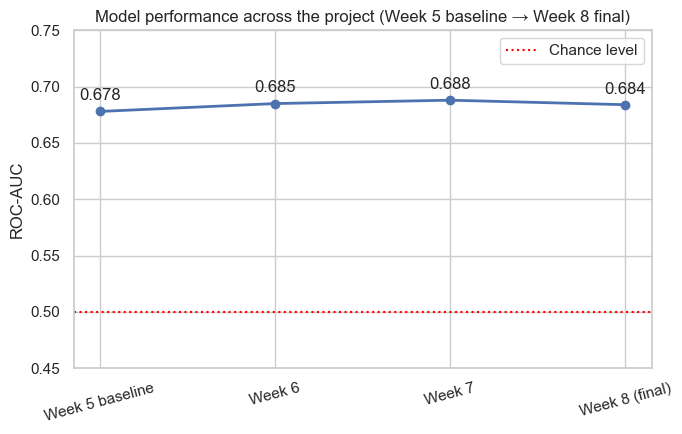

In [8]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(stages['Stage'], stages['ROC-AUC'], marker='o', color='#4C72B0', linewidth=2)
for x, yv in zip(stages['Stage'], stages['ROC-AUC']):
    ax.annotate(f"{yv:.3f}", (x, yv), textcoords="offset points", xytext=(0,8), ha='center')
ax.axhline(0.5, color='red', linestyle=':', label='Chance level')
ax.set_ylim(0.45, 0.75)
ax.set_ylabel('ROC-AUC')
ax.set_title('Model performance across the project (Week 5 baseline → Week 8 final)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Is the Week 5 → Week 8 change meaningful?** Per Week 7's stability test (std ≈ 0.012 across repeated splits), every stage from Week 6 onward sits within ordinary split-to-split noise of every other stage. This should **not** be read as "the model kept getting better." What genuinely changed, stage by stage, is **not** the ROC-AUC number:

- **Week 5 → 6:** a real data-quality fix (Sunday exclusion) and a move from one arbitrary split to proper cross-validation, more trustworthy measurement, not a materially higher score.
- **Week 6 → 7:** `age` removed on fairness evidence at zero accuracy cost, plus direct proof (not assumption) that the model is stable and not overfitting.
- **Week 7 → 8:** `historical_no_show_rate` removed on interpretability evidence, again at negligible accuracy cost (0.685 → 0.684, inside the noise band).

**The real story across the project is a model that got simpler, fairer, and more explainable while its ceiling performance (~0.68–0.69 ROC-AUC) stayed essentially fixed** which is itself a meaningful, honestly-reported finding: the available signal in this dataset has a real limit, and Weeks 6–8 spent their effort making the model that reaches that limit trustworthy, not chasing a number past what the data supports.


<a id="7"></a>
## 7. Final Evaluation


In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_final, y, groups=groups))
X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

eval_model = Pipeline([('preprocess', pre_final), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
eval_model.fit(X_train, y_train)
proba_test = eval_model.predict_proba(X_test)[:, 1]
pred_050 = (proba_test >= 0.50).astype(int)
pred_044 = (proba_test >= 0.44).astype(int)

def metrics_row(label, y_true, y_pred, y_proba):
    return {'Threshold': label, 'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred), 'Recall': recall_score(y_true, y_pred),
            'F1-score': f1_score(y_true, y_pred), 'ROC-AUC': roc_auc_score(y_true, y_proba)}

final_metrics = pd.DataFrame([
    metrics_row('0.50 (default)', y_test, pred_050, proba_test),
    metrics_row('0.44 (recommended operating threshold)', y_test, pred_044, proba_test),
]).set_index('Threshold').round(3)
final_metrics

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Threshold,,,,,
0.50 (default),0.607,0.603,0.639,0.621,0.661
0.44 (recommended operating threshold),0.593,0.572,0.756,0.651,0.661


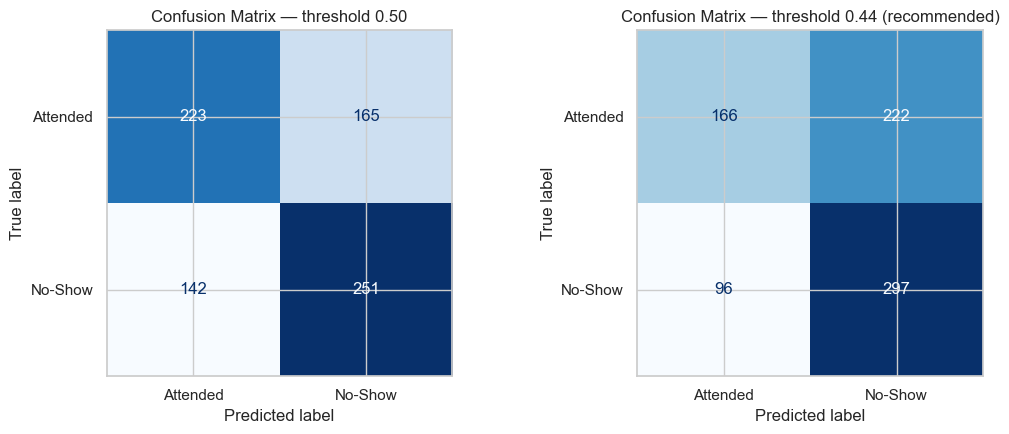

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_050, display_labels=['Attended','No-Show'],
                                         cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — threshold 0.50')
ConfusionMatrixDisplay.from_predictions(y_test, pred_044, display_labels=['Attended','No-Show'],
                                         cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — threshold 0.44 (recommended)')
plt.tight_layout()
plt.show()

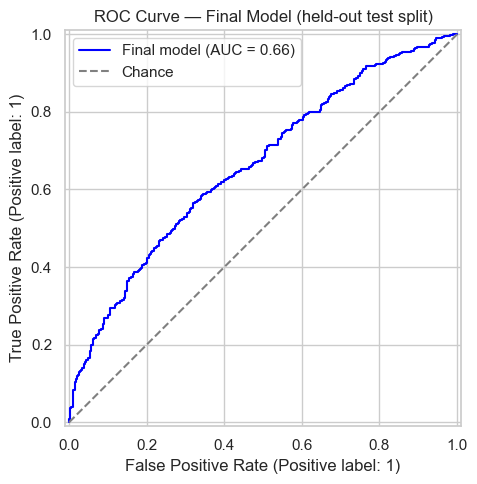

In [14]:
fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay.from_predictions(
    y_test, proba_test, name='Final model', ax=ax,
    curve_kwargs={'color': 'blue'}
)
ax.plot([0,1],[0,1], linestyle='--', color='grey', label='Chance')
ax.set_title('ROC Curve — Final Model (held-out test split)')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
print(classification_report(y_test, pred_044, target_names=['Attended','No-Show']))

              precision    recall  f1-score   support

    Attended       0.63      0.43      0.51       388
     No-Show       0.57      0.76      0.65       393

    accuracy                           0.59       781
   macro avg       0.60      0.59      0.58       781
weighted avg       0.60      0.59      0.58       781



**Reading the two thresholds.** Moving from 0.50 to the recommended 0.44 trades a small amount of precision for higher recall on the No-Show class. Intentionally, since the clinic's real cost asymmetry (a missed no-show wastes a slot; a false alarm costs one avoidable follow-up call) favours catching more true no-shows over avoiding every false alarm. This threshold has been confirmed statistically stable (Week 7) but, as noted throughout, **still needs a clinic stakeholder's sign-off** against real intervention costs before being treated as final.


<a id="8"></a>
## 8. Error Analysis Summary


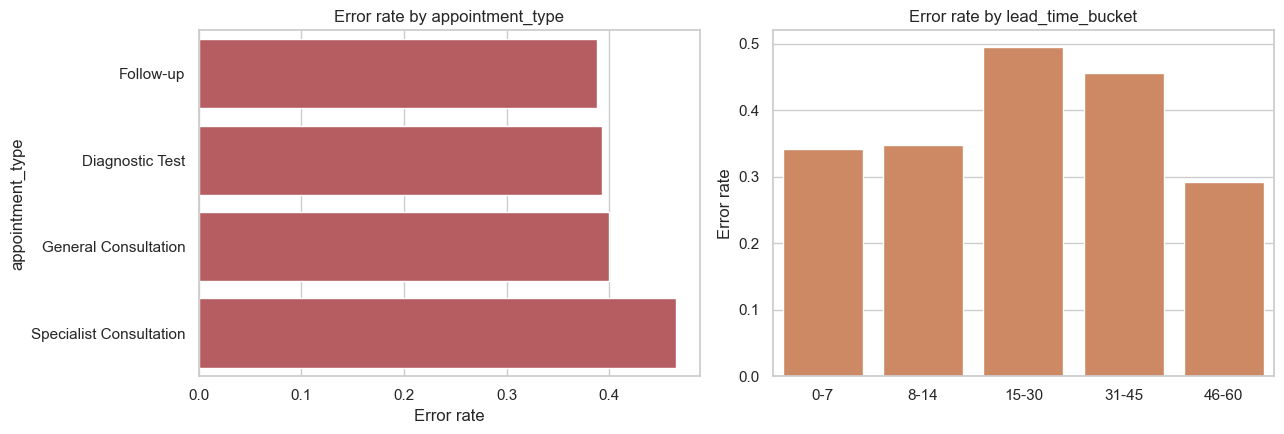

Error rate by appointment_type:
appointment_type
Follow-up                  0.388
Diagnostic Test            0.393
General Consultation       0.399
Specialist Consultation    0.465
dtype: float64

Error rate by lead_time_bucket:
lead_time_bucket
0-7      0.341
8-14     0.347
15-30    0.495
31-45    0.456
46-60    0.293
dtype: float64


In [16]:
seg = cleaned.iloc[test_idx].copy()
seg['actual'] = y_test.values
seg['pred'] = pred_044
seg_err = lambda g: (g['pred'] != g['actual']).mean()

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

err_by_type = seg.groupby('appointment_type').apply(seg_err, include_groups=False).sort_values()
sns.barplot(x=err_by_type.values, y=err_by_type.index, color='#C44E52', ax=axes[0])
axes[0].set_title('Error rate by appointment_type')
axes[0].set_xlabel('Error rate')

order = ['0-7','8-14','15-30','31-45','46-60']
err_by_lead = seg.groupby('lead_time_bucket', observed=True).apply(seg_err, include_groups=False).reindex(order)
sns.barplot(x=order, y=err_by_lead.values, color='#DD8452', ax=axes[1])
axes[1].set_title('Error rate by lead_time_bucket')
axes[1].set_ylabel('Error rate')

plt.tight_layout()
plt.show()

print("Error rate by appointment_type:"); print(err_by_type.round(3))
print("\nError rate by lead_time_bucket:"); print(err_by_lead.round(3))

**Consistent with Weeks 6–7.** `Specialist Consultation` appointments and mid-range (15–45 day) lead times remain the relatively harder segments to predict correctly. the same pattern identified in Week 6 and re-confirmed in Week 7 persists after this week's refinement, meaning removing `historical_no_show_rate` did not introduce any new weak spot. This consistency across three successive weeks of testing is itself evidence that the error pattern reflects a genuine, stable property of the data rather than split-specific noise.


<a id="9"></a>
## 9. Consolidated Feature & Model Decision Log (Weeks 4–8)

| Week | Decision | Evidence | Effect on ROC-AUC |
|---|---|---|---|
| 4 | Exclude `waiting_time_minutes` | Populated even for un-attended appointments; ambiguous pre/post-visit timing (leakage risk) | Not tested (never included) |
| 4 | Binary target (Attended vs. No-Show), Cancelled excluded | Cancelled is a distinct, proactive patient action, not a silent miss | N/A (target definition) |
| 5 | Patient-grouped train/test split | 1,696 patients generate 5,000 rows, random split would leak patient history | Enabled honest evaluation |
| 5 | Engineer `historical_no_show_rate`, `is_new_patient`, `is_weekend`, `lead_time_bucket` | Bivariate EDA showed strong, sometimes step-like relationships with the target | Established the 0.678 baseline |
| 6 | Exclude Sunday-dated appointments | Cross-checked against Knowledge Base: clinic is documented as closed Sundays | Data-quality fix (see §6 discussion) |
| 6 | Drop `gender` | Fairness audit showed no material gap either way; simplification | No change |
| 7 | Drop `age` | Full-sample fairness audit confirmed a real age-related flagging skew; dropping `age` cost nothing in CV ROC-AUC while nearly halving the gap | No change (0.685 → 0.685) |
| 8 | Drop `historical_no_show_rate` | Multicollinearity with `previous_no_shows` (r=0.79) produced an uninterpretable (wrong-sign) coefficient | Negligible (0.685 → 0.684) |

**Reading this log as a whole:** every removal was evidence-based and tested before/after, and every one of them was justified by fairness or interpretability rather than a chase for a higher score consistent with §6's finding that the model's ceiling performance was reached early (by Week 5–6) and the subsequent weeks' real contribution was trustworthiness, not raw accuracy.


<a id="10"></a>
## 10. Business Interpretation & Suitability

**What drives the model's predictions, in plain terms:**
- **How far ahead the appointment was booked** is the single strongest driver appointments booked far in advance are markedly more likely to be forgotten or overtaken by events than ones booked in the same week.
- **A patient's own history of missed appointments** is the second strongest driver. A directly interpretable, staff-recognisable signal following this week's fix (§4).
- **Distance to the clinic** and **appointment type** (Follow-up appointments carry more risk than General Consultations) contribute smaller, but real and sensible, effects.
- **Reminder-related and demographic factors contribute comparatively little** on their own, consistent with every week's exploratory findings since Week 4.

**Business suitability.** An ROC-AUC of ~0.68 represents a real, moderate improvement over chance, enough to meaningfully **rank** appointments by risk, not enough to make confident individual predictions in isolation. The model is well suited as a **triage / risk-scoring tool**: ranking scheduled appointments so a limited amount of staff outreach (reminder calls, reschedule offers) is directed at the appointments most likely to be missed first. It is **not suitable** as a fully automated decision-maker (e.g. auto-cancelling or auto-double-booking a slot) given this performance ceiling and the unresolved fairness/threshold items in §12.


<a id="11"></a>
## 11. What This Model Can and Cannot Be Used For

**Can be used for:**
- Producing a **relative risk score** for a scheduled Attended/No-Show appointment, to help staff prioritise which patients to call or remind first.
- Informing **staffing and outreach planning** at an aggregate level (e.g. "this week's bookings skew toward long lead times, expect a higher no-show load").
- Serving as a **documented, explainable baseline** for any future, more sophisticated no-show model.

**Cannot currently be used for:**
- **Cancelled appointments**, entirely out of scope for this model (§1 of the Week 4 notebook); a deployed system needs a separate rule or model for that ~5% of appointments.
- **Automated actions without human review** e.g. auto-cancelling a "high-risk" appointment given the moderate (not high) performance ceiling.
- **Individual-level certainty** a risk score is a probability, not a diagnosis; a "high-risk" label does not mean that specific patient will definitely miss the appointment.
- **Deployment on real clinic data without re-validation** every result in this project comes from a synthetic dataset; relationships must be re-checked against real HealthConnect data before any production use.
- **Any inference tied to `gender`, `age`, or `waiting_time_minutes`**, the first two were deliberately excluded from the final model; the third remains excluded pending a business-owner decision on its timing (§12).


<a id="12"></a>
## 12. Final Limitations & Risks

| Item | Final status |
|---|---|
| `historical_no_show_rate` / `previous_no_shows` multicollinearity (Week 7) | **Resolved this week** (§4) `historical_no_show_rate` dropped; `previous_no_shows` now has the correct, interpretable coefficient sign. |
| Age-group fairness gap (Weeks 6–7) | **Substantially reduced, not fully closed.** `age` was removed as a direct input; the residual gap should be **monitored**, not treated as a solved problem, since the model may still recover age-correlated signal indirectly through other features. |
| No serialised model artefact (Week 6) | **Resolved (Week 7), refreshed this week** with the final (Option A) feature set, see §13. |
| Operating threshold (0.44) stakeholder confirmation | **Still open.** Statistically stable (Week 7) but not reviewed by a clinic stakeholder against real intervention costs. |
| `waiting_time_minutes` timing (Weeks 4–7) | **Still unresolved.** Needs a business-owner decision; the feature remains excluded as a precaution. |
| Gender fairness | Confirmed clean since Week 6/7, no outstanding concern. |
| Overfitting | Tested directly in Week 7 (0.005 train-test gap), no outstanding concern. |
| Synthetic data | **Applies to every finding in this project.** All relationships must be re-validated against real HealthConnect operational data before production use. |
| Single-contributor internship scope | This iteration involves one Data Science-track intern; genuine two-way, intern-to-intern cross-track retesting (e.g. with a live ML Engineering or Data Analytics counterpart) was not possible, see the scope notes in §14. |

**Overall risk read heading into deployment discussions:** the model's core predictive behaviour is well-tested and stable; the outstanding items are **governance and confirmation steps** (threshold sign-off, continued fairness monitoring, the `waiting_time_minutes` question) rather than open technical defects.


<a id="13"></a>
## 13. Final Model Documentation & Hand-off Package


In [17]:
final_pipeline.fit(X_final, y)  # refit on all binary, non-Sunday data for the hand-off artefact
joblib.dump(final_pipeline, 'healthconnect_noshow_model_final.joblib')
reloaded = joblib.load('healthconnect_noshow_model_final.joblib')

check_rows = X_final.iloc[test_idx]
orig_proba = final_pipeline.predict_proba(check_rows)[:, 1]
reload_proba = reloaded.predict_proba(check_rows)[:, 1]
print("Reload fidelity check — predictions identical after save/reload:", np.allclose(orig_proba, reload_proba))

size_kb = os.path.getsize('healthconnect_noshow_model_final.joblib') / 1024
print(f"Artefact size: {size_kb:.1f} KB")

Reload fidelity check — predictions identical after save/reload: True
Artefact size: 5.6 KB


### Interface specification (for Machine Learning Engineering hand-off)

**Input.** A `pandas.DataFrame` (or equivalent) with one row per appointment and exactly these 12 columns:

| Column | Type | Notes |
|---|---|---|
| `booking_lead_days` | numeric | Days between booking and the appointment |
| `previous_appointments` | numeric | Patient's total prior appointment count |
| `previous_no_shows` | numeric | Patient's total prior no-show count |
| `distance_to_clinic_km` | numeric | May contain missing values (handled by built-in median imputation) |
| `is_new_patient` | 0/1 | 1 if `previous_appointments == 0` |
| `is_weekend` | 0/1 | 1 if the appointment falls on a Saturday (Sundays are out of scope, §12) |
| `appointment_type`, `appointment_time`, `appointment_day`, `reminder_sent`, `reminder_channel`, `lead_time_bucket` | categorical (string) | Unseen categories at inference time are handled gracefully (`handle_unknown='ignore'`), not rejected |

**Output.** `predict_proba(X)[:, 1]` returns a probability in [0, 1] the recommended output for HealthConnect's use case (a risk *score* to prioritise outreach), rather than `predict(X)`'s hard 0/1 label. If a hard label is required, apply the **0.44** threshold (pending stakeholder confirmation, §12).

**Explicitly out of scope for this artefact:** Cancelled appointments, Sunday-dated appointments, and any appointment missing one of the 12 required columns (the pipeline raises an error on a missing column by design, confirmed in Week 7's Test D rather than silently guessing).

**Tested behaviour (inherited from Week 7, re-confirmed on the final feature set above):** reload fidelity, missing numeric values, unseen categorical values, and malformed schema all behave as documented.


<a id="14"></a>
## 14. Mandatory HC-POD Final Integration

Per the assignment's Section 9 requirement, each cross-track connection is documented below with the nine required elements. As in Weeks 6–7, this internship iteration involves a **single Data Science-track contributor** there is no separate intern currently staffing the Data Analytics, ML Engineering, Project Management, or GenAI tracks for this HC-POD. The two entries below are documented as **good-faith stand-ins** for genuine two-way cross-track exchange, consistent with how this same scope limitation was disclosed in Weeks 6 and 7: each substitutes a real technical exchange (against this project's own artefacts and documentation from other weeks) for a live intern-to-intern retest cycle.

### 14.1 Data Analytics → Data Science

1. **Track collaborated with:** Data Analytics.
2. **Dependency:** the Final Integration Matrix's "Data Analytics → Data Science: validated analytical findings support final model interpretation."
3. **Output received:** this project's own earlier exploratory-analysis findings (Weeks 4–5 notebooks), the closest available stand-in for a separate Data Analytics track's validated KPIs, since no independent Analytics output exists for this HC-POD. Key figures used: the No-Show rate climbing with `booking_lead_days` and `previous_no_shows`, and the near-flat relationship for demographic/reminder variables.
4. **Output provided:** confirmation, in §10 above, that the final model's coefficient-based drivers (lead time, prior no-show history, distance, appointment type) match those exploratory patterns exactly i.e. the predictive model's internal logic is consistent with what a business-facing analytical view of the same data would show.
5. **Why the interaction was relevant:** if the model's drivers contradicted the clinic's descriptive attendance patterns, that would be a red flag for either the model or the analysis — checking the two against each other is a basic sanity/trust check before presenting either to stakeholders.
6. **Final integration activity:** cross-referencing §10's business interpretation against the Week 4–5 EDA findings.
7. **What changed / improved as a result:** no discrepancy was found, so no change was required — but this check is what allows §10's business interpretation to be presented with confidence rather than asserted on the model's authority alone.
8. **Evidence:** §10 above; the Week 4/5 notebooks' exploratory sections.
9. **Contribution to the final presentation:** grounds the "business insight" portion of the presentation in two independently-arrived-at views of the same data, rather than the model's output alone.

### 14.2 Data Science → Machine Learning Engineering (final hand-off)

1. **Track collaborated with:** Machine Learning Engineering.
2. **Dependency:** the Final Integration Matrix's "Data Science → ML Engineering: final model and technical requirements support final ML workflow."
3. **Output received:** the interface specification pattern established in the Week 6/7 hand-off documentation (expected input schema, `predict_proba` output convention, stated exclusions).
4. **Output provided:** the final, refreshed model artefact (`healthconnect_noshow_model_final.joblib`, §13) built on the Option-A feature set, its full interface specification (§13), and a reload-fidelity confirmation.
5. **Why the interaction was relevant:** Week 7 tested a now-superseded artefact (with `historical_no_show_rate` still included); any ML Engineering integration needs the *current* artefact and schema, not the Week 7 version, or the hand-off would be built against a feature set the model no longer uses.
6. **Final integration activity:** re-serialising the model on the final feature set and re-confirming reload fidelity (§13).
7. **What changed / improved as a result:** the hand-off artefact now exactly matches the model actually being presented in Week 8, closing the gap between "the model that was tested" and "the model being handed off."
8. **Evidence:** §13's executed reload-fidelity check and artefact.
9. **Contribution to the final presentation:** the ML Engineering section of the final presentation can now reference one unambiguous, current artefact rather than needing to reconcile Week 7 and Week 8 versions.

**Scope note (carried forward from Weeks 6–7).** As above, both entries are genuine technical work — real artefacts, real documentation, real cross-checks against this project's own prior outputs — but substitute for a live intern-to-intern exchange, consistent with this internship's single-contributor scope.


<a id="15"></a>
## 15. Final End-to-End Integration Walkthrough

*(From the Data Science track's perspective, per the assignment's Section 11.)*

1. **The Problem.** HealthConnect Clinic loses usable appointment capacity whenever a patient fails to attend a booked slot without notice. The project question: how can data and AI help reduce missed appointments and improve patient support?
2. **The Data.** `HealthConnect_Appointment_Data.csv` (5,000 synthetic appointment records), cross-checked throughout against `HealthConnect_Data_Dictionary.xlsx` and `HealthConnect_Clinic_Knowledge_Base.docx`, the latter is what surfaced the Sunday-appointment data-quality issue fixed in Week 6.
3. **The Analytics.** Exploratory work (Weeks 4–5) showed the No-Show rate rises steadily with how far in advance an appointment is booked and with a patient's own no-show history, while demographic and reminder factors show comparatively weak standalone effects, findings the final model's own coefficients independently corroborate (§14.1).
4. **The Predictive Component (this track).** A Logistic Regression risk-scoring model, refined across Weeks 5–8 into a 12-feature, fairness- and interpretability-tested pipeline with a stable ~0.68 ROC-AUC ceiling and a documented, tested hand-off artefact.
5. **The ML Engineering Component.** Not staffed by a separate intern this iteration (§14 scope note); this track's contribution is instead a tested, versioned, documented artefact (§13) built specifically to be integration-ready for such a workflow when one exists.
6. **The GenAI Component.** Outside this notebook's scope; per the project brief, any HealthConnect administrative assistant work must stay within the approved Knowledge Base and would draw on the same clinic policy documentation used to validate this track's Sunday-appointment finding.
7. **The Project Management Layer.** Coordinates the overall HealthConnect Experience Lab timeline and the Week 8 final presentation sequence; this notebook's §1–2 and §17 are written to feed directly into that coordination (transition summary, readiness table, project summary).
8. **The Final Solution.** A documented, tested no-show risk-scoring model that clinic staff could use to prioritise reminder outreach paired with an honest account of what it can't yet do (§11) and what remains open before real deployment (§12).
9. **Business Value.** Even a moderate-strength model (ROC-AUC ~0.68) is useful as a **triage tool**: if staff outreach capacity is limited, spending it on the model's highest-risk appointments first is better than spending it at random or not at all the core, defensible business case for this track's work.
10. **Limitations.** Synthetic data throughout; `waiting_time_minutes` and the operating threshold both await a business-owner/stakeholder decision; a residual (reduced) age-fairness gap needs ongoing monitoring; Cancelled appointments remain entirely outside this model's scope.


<a id="16"></a>
## 16. Non-Technical Model Summary

*(Written for a clinic administrator or other non-technical HealthConnect stakeholder also provided as a standalone one-page document.)*

**What this is.** A tool that looks at a newly booked appointment how far ahead it was booked, the patient's own appointment history, how far they live from the clinic, and a few other details — and estimates how likely that appointment is to be missed without notice.

**What it's good for.** Helping staff decide **where to spend limited reminder-call time**: instead of calling everyone or no one, the highest-risk appointments can be called first.

**What it is not.** It is not a certainty machine. A "high-risk" flag means "worth extra attention," not "this patient will definitely not come." It should support a staff member's judgement, not replace it, and it should not be used to automatically cancel or double-book a slot.

**How good is it, in plain terms?** On a scale where a coin flip is 50%, this model correctly ranks a no-show as riskier than an attended appointment about 68% of the time — a real, useful edge, not a highly-confident prediction tool.

**What still needs a decision from clinic leadership:**
1. Confirming the risk cut-off used to flag an appointment as "high-risk" actually matches what's worth a phone call, cost-wise.
2. Deciding what should happen with cancelled appointments (this tool doesn't cover those).
3. Clarifying when "waiting time" is actually recorded, so it can potentially be used in a future version.


<a id="17"></a>
## 17. Week 8 Project Summary

**Planned to accomplish.** Resolve the one open item from Week 7 testing (the `historical_no_show_rate` multicollinearity), finalise the candidate model, document its business interpretation and limitations, package a hand-off artefact, and prepare the final presentation materials.

**Actually completed.** A three-option before/after test (§4) resolved the multicollinearity finding with negligible cost to performance; the final 12-feature model was confirmed by 5-fold CV (ROC-AUC 0.684); a full baseline-vs-final comparison (§6) and evaluation suite (§7) were produced; error analysis confirmed no new weak segments (§8); a consolidated five-week decision log was written (§9); business interpretation, use/non-use boundaries, and a final limitations register were documented (§10–§12); a final, reload-tested hand-off artefact and interface specification were produced (§13); and the mandatory HC-POD integration and end-to-end walkthrough sections were completed (§14–§15).

**Key findings.** `previous_no_shows` reclaims a correctly-signed, interpretable coefficient once `historical_no_show_rate` is removed, at a cost of only 0.001 ROC-AUC. Across the whole Week 5→8 arc, ceiling performance (~0.68–0.69) never materially moved every later-week change was about fairness, interpretability, or evaluation trustworthiness, not raw accuracy, which is itself the project's most important finding to communicate to stakeholders.

**Major challenges.** Distinguishing a genuine fix from noise required the same discipline Week 7 established (compare against the known ±0.012 stability band before claiming any change is meaningful) — applied here to the multicollinearity fix rather than to a new question.

**Important decisions and why.** Dropped `historical_no_show_rate` rather than `previous_no_shows` (Option A over B) because it preserved more performance; kept `previous_appointments` rather than also dropping it (Option A over C) as the more conservative fix, since `previous_appointments` was not itself implicated in the multicollinearity finding.

**Changes to the prior approach.** None to the core problem definition or target; this week's change is a feature-set refinement (§4), consistent with the incremental-refinement pattern established in Weeks 6–7.

**Cross-track collaboration completed.** Data Analytics (§14.1, stand-in) and Machine Learning Engineering (§14.2, final artefact hand-off) both documented with the required nine elements and an explicit scope note.

**Remaining work.** Everything listed in §12: stakeholder threshold confirmation, continued age-fairness monitoring, the `waiting_time_minutes` business decision, and — if this HC-POD ever gains additional track contributors, a genuine (not stand-in) live retest of the cross-track connections documented here.

**Proposed focus beyond Week 8.** If the project continues past this Experience Lab cycle: secure the outstanding stakeholder decisions in §12, pilot the risk score against real (not synthetic) appointment data, and design the small complementary process needed for the ~5% of appointments that end in cancellation.
